In [48]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from PIL import Image
from tensorflow_examples.models.pix2pix import pix2pix
from IPython.display import clear_output

In [49]:
USE_TEST_FOR_TRAINING = True
HEIGHT, WIDTH = 512, 512 # to which size should the image be compressed

training_data = []
test_data = []
validation_data = []

for i in range(1, 161):
    training_data.append({"image": 'data/train/image/image' + str(i) + '.bmp',
                      "segmentation_mask": 'data/train/label/' + str(i) + '.bmp'})
for i in range(161, 181):
    validation_data.append({"image": 'data/validation/image/image' + str(i) + '.bmp',
                            "segmentation_mask": 'data/validation/label/' + str(i) + '.bmp'})
for i in range(181, 225):
    if USE_TEST_FOR_TRAINING:
        training_data.append({"image": 'data/test/image/image' + str(i) + '.bmp',
                              "segmentation_mask": 'data/test/label/' + str(i) + '.bmp'})
    else:
        test_data.append({"image": 'data/test/image/image' + str(i) + '.bmp',
                          "segmentation_mask": 'data/test/label/' + str(i) + '.bmp'})
    
def load_image(image_path, mask_path):
    image = tf.io.read_file(image_path)
    image = tf.image.decode_bmp(image)
    mask = Image.open(mask_path)
    mask = np.array(mask)  
    mask = tf.convert_to_tensor(mask, dtype=tf.float32)
    # Error in dataset: some data has 255 instead of 1 as class
    mask = tf.where(mask == 255, 1, mask)  # Convert 255 to 1
    mask = tf.expand_dims(mask, axis=-1)
    image = tf.cast(image, tf.float32) / 255.0
    # resize because images in database are not the same size
    image = tf.image.resize(image, size=(HEIGHT, WIDTH), method=tf.image.ResizeMethod.NEAREST_NEIGHBOR)
    mask = tf.image.resize(mask, size=(HEIGHT, WIDTH), method=tf.image.ResizeMethod.NEAREST_NEIGHBOR)
    return {"image": image, "mask": mask}

# Create TensorFlow Datasets
train_images_list = [load_image(item['image'], item['segmentation_mask']) for item in training_data]

validation_images_list = [load_image(item['image'], item['segmentation_mask']) for item in validation_data]

test_images_list = [load_image(item['image'], item['segmentation_mask']) for item in test_data]

dataset = {
    'train': train_images_list,
    'validation': validation_images_list,
    'test': test_images_list
}

In [50]:
# for datapoint in dataset['train']:
#     print("Image shape:", datapoint['image'].shape)
#     print("Mask shape:", datapoint['mask'].shape)

print(dataset['train'][0]['image'].shape)
print(dataset['train'][0]['mask'].shape)

unique_entries = tf.unique(tf.reshape(dataset['train'][0]['mask'], [-1]))
print("Unique entries in mask tensor:", unique_entries.y.numpy())

(512, 512, 3)
(512, 512, 1)
Unique entries in mask tensor: [0. 1.]


In [51]:
TRAIN_LENGTH = len(dataset['train'])
BATCH_SIZE = 64
BUFFER_SIZE = 1000
STEPS_PER_EPOCH = TRAIN_LENGTH // BATCH_SIZE

def get_image(datapoint):
  return datapoint['image']
def get_mask(datapoint):
  return datapoint['mask']
  
def unpack_datapoint(datapoint):
  return datapoint['image'], datapoint['mask']

train_images_tensor = tf.convert_to_tensor([get_image(datapoint) for datapoint in dataset['train']])
train_labels_tensor = tf.convert_to_tensor([get_mask(datapoint) for datapoint in dataset['train']])
train_images = tf.data.Dataset.from_tensor_slices((train_images_tensor, train_labels_tensor))

test_images_tensor = tf.convert_to_tensor([get_image(datapoint) for datapoint in dataset['test']])
test_labels_tensor = tf.convert_to_tensor([get_mask(datapoint) for datapoint in dataset['test']])
test_images = tf.data.Dataset.from_tensor_slices((test_images_tensor, test_labels_tensor))

validation_images_tensor = tf.convert_to_tensor([get_image(datapoint) for datapoint in dataset['validation']])
validation_labels_tensor = tf.convert_to_tensor([get_mask(datapoint) for datapoint in dataset['validation']])
validation_images = tf.data.Dataset.from_tensor_slices((validation_images_tensor, validation_labels_tensor))


class Augment(tf.keras.layers.Layer):
  def __init__(self, seed=42):
    super().__init__()
    # both use the same seed, so they'll make the same random changes.
    self.augment_inputs = tf.keras.layers.RandomFlip(mode="horizontal", seed=seed)
    self.augment_labels = tf.keras.layers.RandomFlip(mode="horizontal", seed=seed)

  def call(self, inputs, labels):
    inputs = self.augment_inputs(inputs)
    labels = self.augment_labels(labels)
    return inputs, labels
  
train_batches = (
    train_images
    .cache()
    .shuffle(BUFFER_SIZE)
    .batch(BATCH_SIZE)
    .repeat()
    .map(Augment())
    .prefetch(buffer_size=tf.data.AUTOTUNE))

validation_batches = validation_images.batch(BATCH_SIZE)

def display(display_list):
  plt.figure(figsize=(6, 6))

  title = ['Input Image', 'True Mask', 'Predicted Mask']

  for i in range(len(display_list)):
    plt.subplot(1, len(display_list), i+1)
    plt.title(title[i])
    plt.imshow(tf.keras.utils.array_to_img(display_list[i]))
    plt.axis('off')
  plt.show()

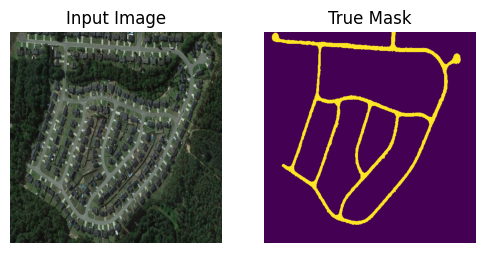

In [52]:
for images, masks in train_batches.take(1):
    sample_image, sample_mask = images[0], masks[0]
    display([sample_image, sample_mask])

In [53]:
# Define the model
# Econder ist pretrained MobileNetV2 (64x64 -> 4x4)
base_model = tf.keras.applications.MobileNetV2(input_shape=[HEIGHT, WIDTH, 3], include_top=False)

# Use the activations of these layers
layer_names = [
    'block_1_expand_relu',   # 64x64
    'block_3_expand_relu',   # 32x32
    'block_6_expand_relu',   # 16x16
    'block_13_expand_relu',  # 8x8
    'block_16_project',      # 4x4
]
base_model_outputs = [base_model.get_layer(name).output for name in layer_names]

# Create the feature extraction model
down_stack = tf.keras.Model(inputs=base_model.input, outputs=base_model_outputs)

down_stack.trainable = False

up_stack = [
    pix2pix.upsample(512, 3),  # 4x4 -> 8x8
    pix2pix.upsample(256, 3),  # 8x8 -> 16x16
    pix2pix.upsample(128, 3),  # 16x16 -> 32x32
    pix2pix.upsample(64, 3),   # 32x32 -> 64x64
]

def unet_model(output_channels:int):
  inputs = tf.keras.layers.Input(shape=[HEIGHT, WIDTH, 3])

  # Downsampling through the model
  skips = down_stack(inputs)
  x = skips[-1]
  skips = reversed(skips[:-1])

  # Upsampling and establishing the skip connections
  for up, skip in zip(up_stack, skips):
    x = up(x)
    concat = tf.keras.layers.Concatenate()
    x = concat([x, skip])

  # This is the last layer of the model
  last = tf.keras.layers.Conv2DTranspose(
      filters=output_channels, kernel_size=3, strides=2,
      padding='same')  #64x64 -> 128x128

  x = last(x)

  return tf.keras.Model(inputs=inputs, outputs=x)

/var/folders/0n/bb4_kwsn3n5c5_7n_mgl2n540000gn/T/ipykernel_19748/2912756410.py:3: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = tf.keras.applications.MobileNetV2(input_shape=[HEIGHT, WIDTH, 3], include_top=False)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 384ms/step


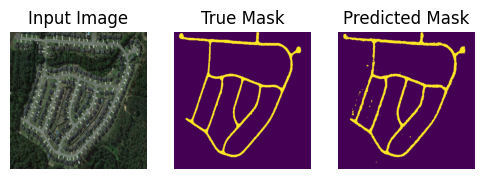


Sample Prediction after epoch 100

3/3 ━━━━━━━━━━━━━━━━━━━━ 111s 32s/step - accuracy: 0.9473 - loss: 0.1749 - val_accuracy: 0.9537 - val_loss: 0.1144


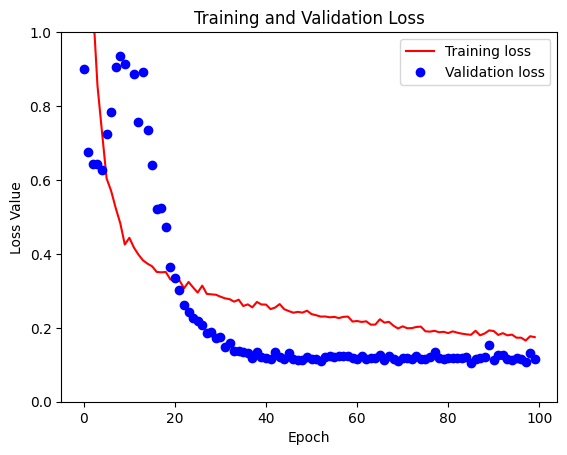

In [ ]:
# Train the model -> takes 215 min.
OUTPUT_CLASSES = 2

model = unet_model(output_channels=OUTPUT_CLASSES)
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

#? Potentially plot model architecture
#? tf.keras.utils.plot_model(model, show_shapes=True, expand_nested=True, dpi=64)

def create_mask(pred_mask):
  pred_mask = tf.math.argmax(pred_mask, axis=-1)
  pred_mask = pred_mask[..., tf.newaxis]
  return pred_mask[0]

def show_predictions(dataset=None, num=1):
  if dataset:
    for image, mask in dataset.take(num):
      pred_mask = model.predict(image)
      display([image[0], mask[0], create_mask(pred_mask)])
  else:
    display([sample_image, sample_mask,
             create_mask(model.predict(sample_image[tf.newaxis, ...]))])

# Show prediction before training
show_predictions()

class DisplayCallback(tf.keras.callbacks.Callback):
  def on_epoch_end(self, epoch, logs=None):
    clear_output(wait=True)
    show_predictions()
    print ('\nSample Prediction after epoch {}\n'.format(epoch+1))

EPOCHS = 100
VAL_SUBSPLITS = 5
VALIDATION_STEPS = len(dataset['validation'])//BATCH_SIZE//VAL_SUBSPLITS

# class weights adjustable
class_weight = {0:1.0, 1:10.0}
model_history = model.fit(train_batches, epochs=EPOCHS,
                          steps_per_epoch=STEPS_PER_EPOCH,
                          validation_steps=VALIDATION_STEPS,
                          validation_data=validation_batches,
                          callbacks=[DisplayCallback()],
                          class_weight = class_weight)

loss = model_history.history['loss']
val_loss = model_history.history['val_loss']

plt.figure()
plt.plot(model_history.epoch, loss, 'r', label='Training loss')
plt.plot(model_history.epoch, val_loss, 'bo', label='Validation loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss Value')
plt.ylim([0, 1])
plt.legend()
plt.show()

# model.save('road_detection_model.keras')

Model: "functional_42"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_38      │ (None, 512, 512,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ functional_37       │ [(None, 256, 256, │  1,841,984 │ input_layer_38[0… │
│ (Functional)        │ 96), (None, 128,  │            │                   │
│                     │ 128, 144), (None, │            │                   │
│                     │ 64, 64, 192),     │            │                   │
│                     │ (None, 32, 32,    │            │                   │
│                     │ 576), (None, 16,  │            │                   │
│                     │ 16, 320)]         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_24       │ (None, 32, 32,    │  1,476,608 │ functional_37[0]… │
│ (Sequential)        │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_28      │ (None, 32, 32,    │          0 │ sequential_24[0]… │
│ (Concatenate)       │ 1088)             │            │ functional_37[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_25       │ (None, 64, 64,    │  2,507,776 │ concatenate_28[0… │
│ (Sequential)        │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_29      │ (None, 64, 64,    │          0 │ sequential_25[0]… │
│ (Concatenate)       │ 448)              │            │ functional_37[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_26       │ (None, 128, 128,  │    516,608 │ concatenate_29[0… │
│ (Sequential)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_30      │ (None, 128, 128,  │          0 │ sequential_26[0]… │
│ (Concatenate)       │ 272)              │            │ functional_37[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_27       │ (None, 256, 256,  │    156,928 │ concatenate_30[0… │
│ (Sequential)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_31      │ (None, 256, 256,  │          0 │ sequential_27[0]… │
│ (Concatenate)       │ 160)              │            │ functional_37[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_35 │ (None, 512, 512,  │      2,882 │ concatenate_31[0… │
│ (Conv2DTranspose)   │ 2)                │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 15,820,552 (60.35 MB)

 Trainable params: 4,658,882 (17.77 MB)

 Non-trainable params: 1,843,904 (7.03 MB)

 Optimizer params: 9,317,766 (35.54 MB)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


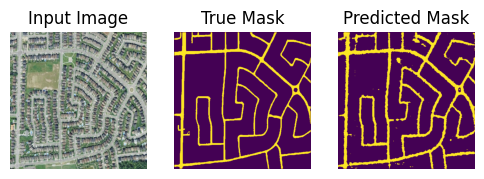

In [66]:
model1 = tf.keras.models.load_model('road_detection_model.keras', custom_objects={'KerasLayer': tf.keras.layers.Layer})
model1.summary()

sample_image, sample_mask = validation_images_list[0]['image'], validation_images_list[0]['mask']

display([sample_image, sample_mask,
             create_mask(model1.predict(sample_image[tf.newaxis, ...]))])


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 596ms/step


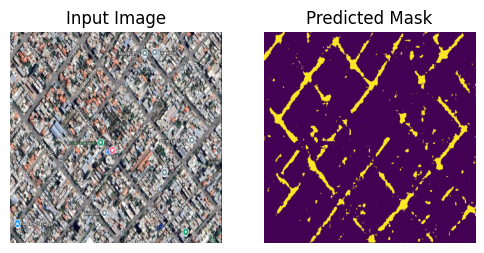

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 395ms/step


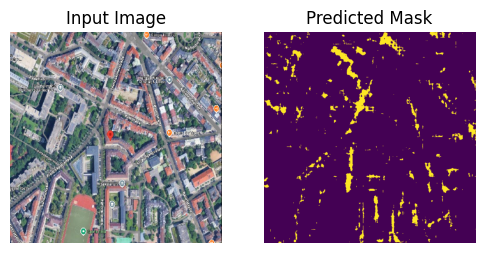

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 422ms/step


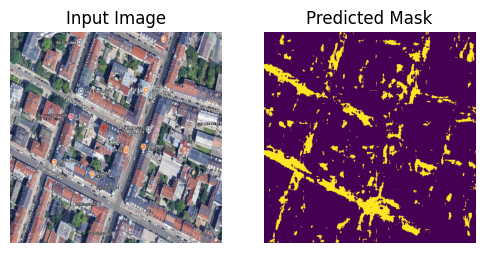

In [65]:
# load png
def load_image_test(image_path):
    image = tf.io.read_file(image_path)
    image = tf.image.decode_png(image, channels=3)
    image = tf.cast(image, tf.float32) / 255.0
    # resize because images in database are not the same size
    image = tf.image.resize(image, size=(HEIGHT, WIDTH), method=tf.image.ResizeMethod.NEAREST_NEIGHBOR)
    return image

def plot_image(image, prediction):
    plt.figure(figsize=(6, 6))
    plt.subplot(1, 2, 1)
    plt.title('Input Image')
    plt.imshow(tf.keras.utils.array_to_img(image))
    plt.axis('off')
    plt.subplot(1, 2, 2)
    plt.title('Predicted Mask')
    plt.imshow(tf.keras.utils.array_to_img(prediction))
    plt.axis('off')
    plt.show()

image = load_image_test('data/manual/1.png')
prediction = create_mask(model.predict(image[tf.newaxis, ...]))
plot_image(image, prediction)

image = load_image_test('data/manual/2.png')
prediction = create_mask(model.predict(image[tf.newaxis, ...]))
plot_image(image, prediction)

image = load_image_test('data/manual/3.png')
prediction = create_mask(model.predict(image[tf.newaxis, ...]))
plot_image(image, prediction)